In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/data.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Dataset Shape:
(95662, 16)

Columns:
Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

Data Types:
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object


In [2]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [3]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

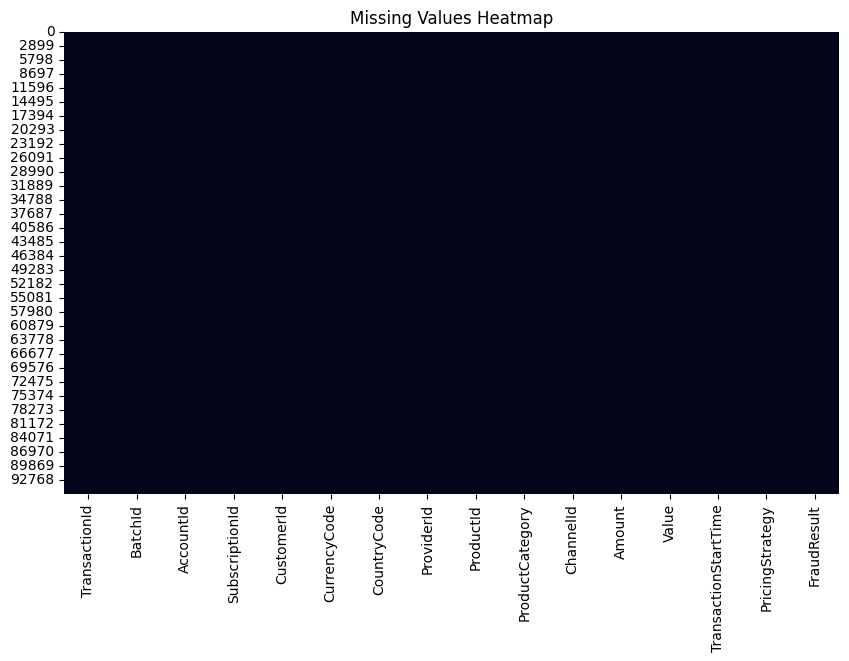

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

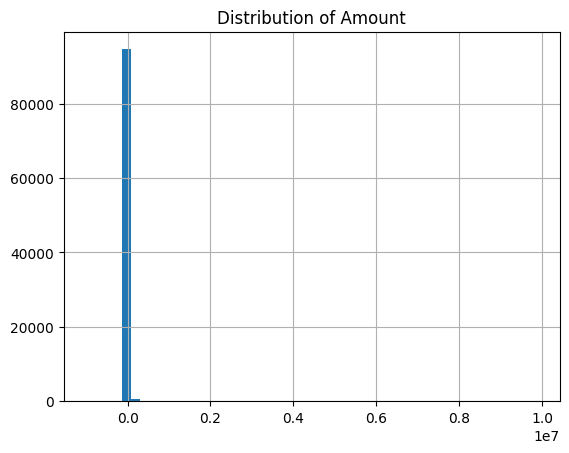

In [5]:
df["Amount"].hist(bins=50)
plt.title("Distribution of Amount")
plt.show()

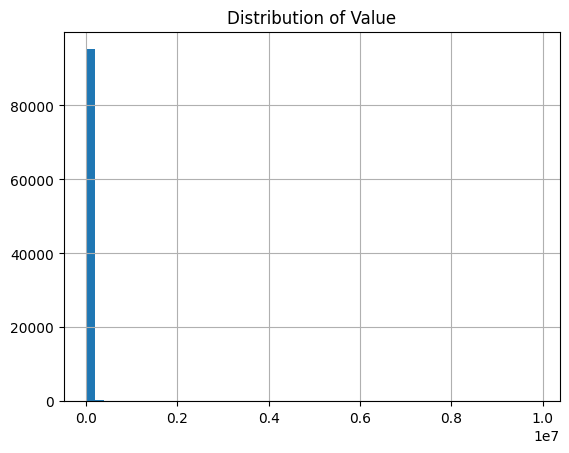

In [6]:
df["Value"].hist(bins=50)
plt.title("Distribution of Value")
plt.show()

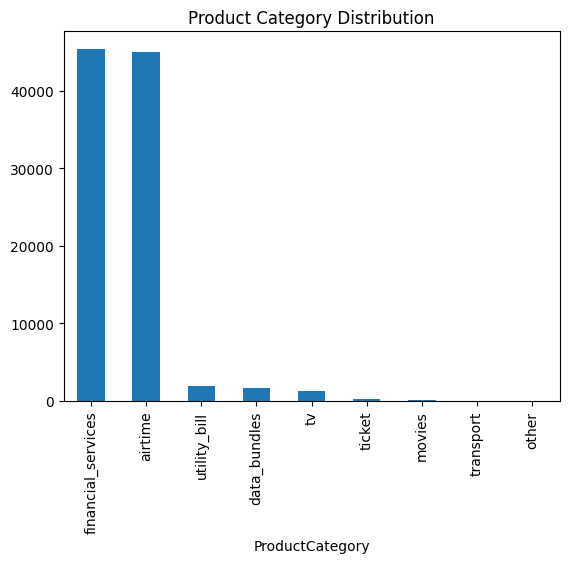

In [7]:
df["ProductCategory"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.show()

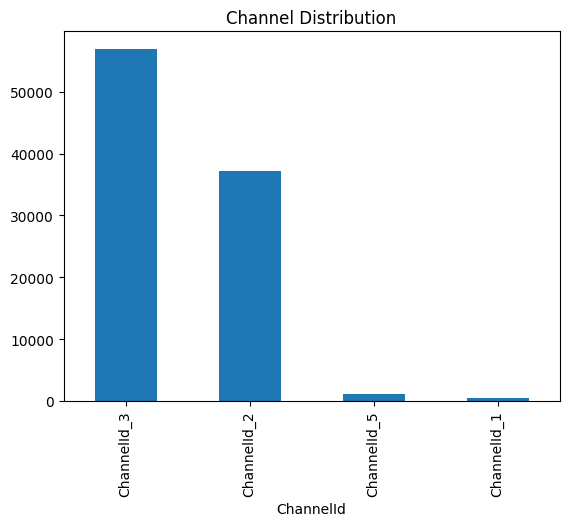

In [8]:
df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Channel Distribution")
plt.show()

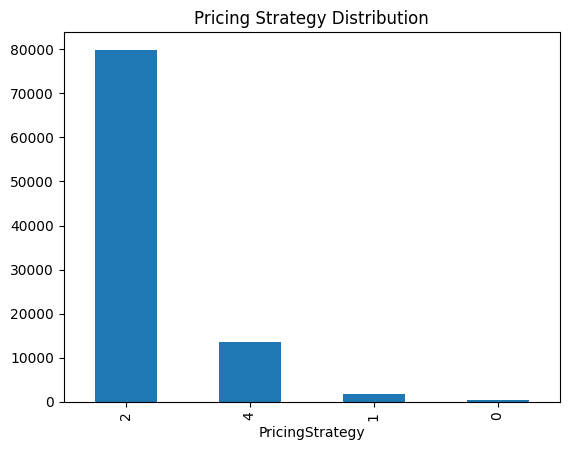

In [9]:
df["PricingStrategy"].value_counts().plot(kind="bar")
plt.title("Pricing Strategy Distribution")
plt.show()

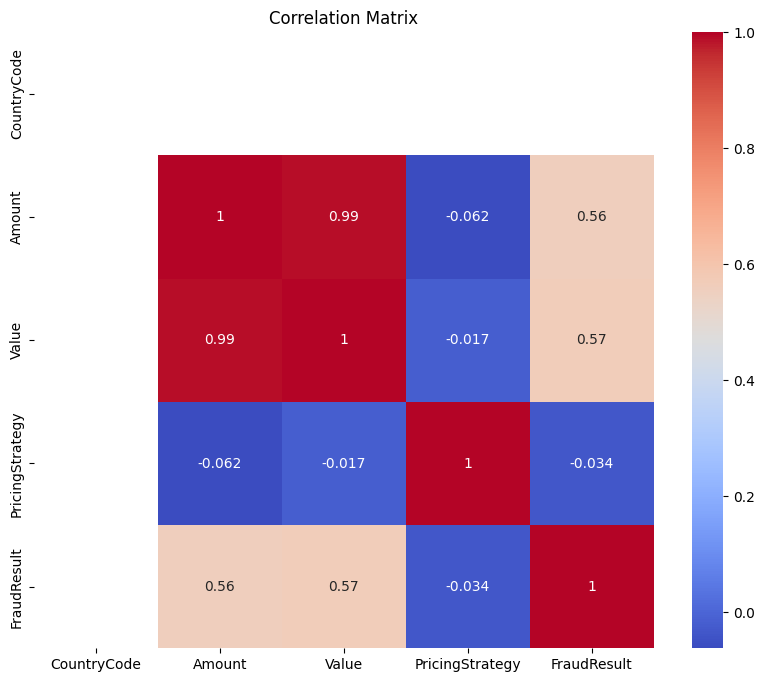

In [10]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

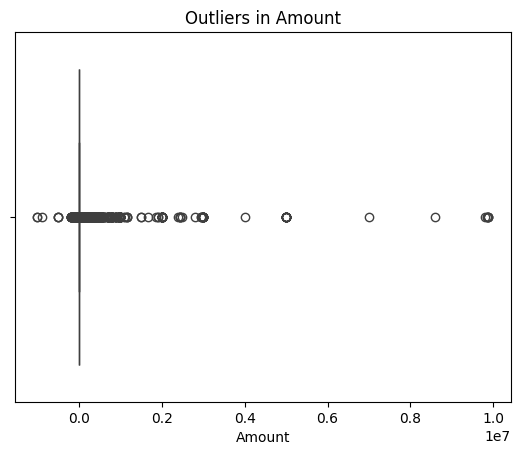

In [11]:
sns.boxplot(x=df["Amount"])
plt.title("Outliers in Amount")
plt.show()

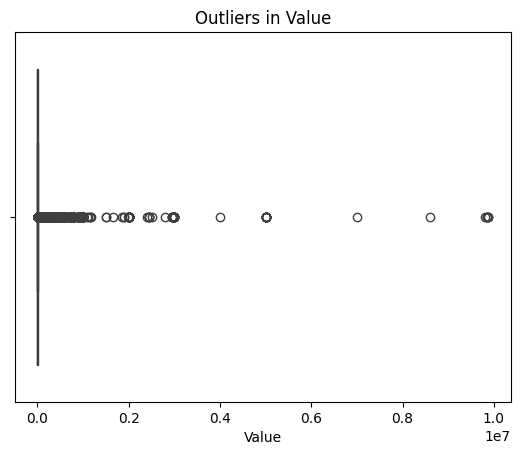

In [12]:
sns.boxplot(x=df["Value"])
plt.title("Outliers in Value")
plt.show()

# Key Insights

1. Transaction amounts show a highly skewed distribution with several extreme outliers.

2. Missing values are limited and can be addressed through imputation during feature engineering.

3. Certain product categories dominate transaction activity, suggesting customer behavior is concentrated in specific services.

4. Strong correlations exist among some transaction variables, indicating potential predictive value.

5. Outliers in Amount and Value may represent high-value customers or unusual transaction behavior and should be carefully treated during modeling.

In [13]:
# Data Overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(95662, 16)

Column Names:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

Data Types:
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object


In [14]:
# Summary Statistics

df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [15]:
# Missing Values

missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

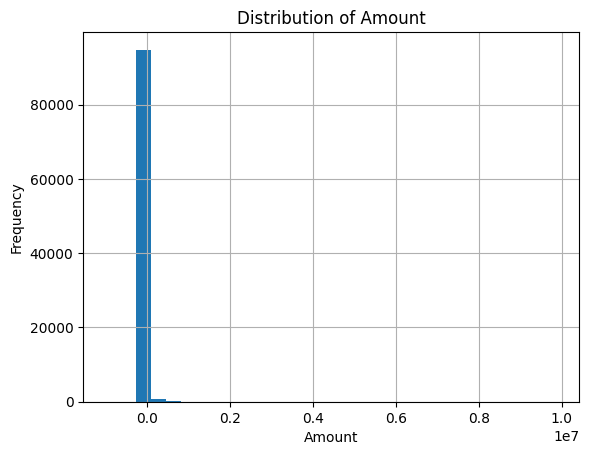

In [16]:
import matplotlib.pyplot as plt

df["Amount"].hist(bins=30)

plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

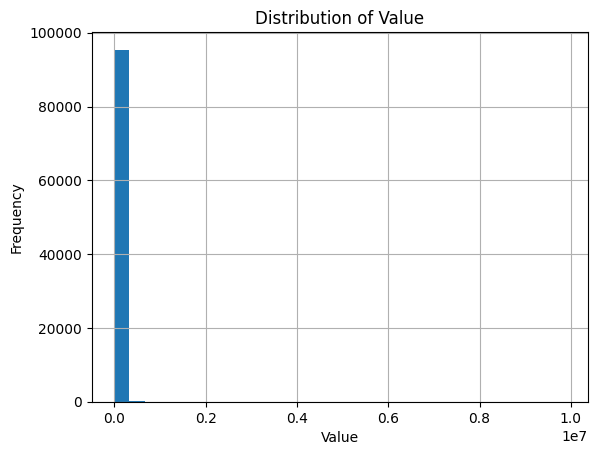

In [17]:
df["Value"].hist(bins=30)

plt.title("Distribution of Value")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

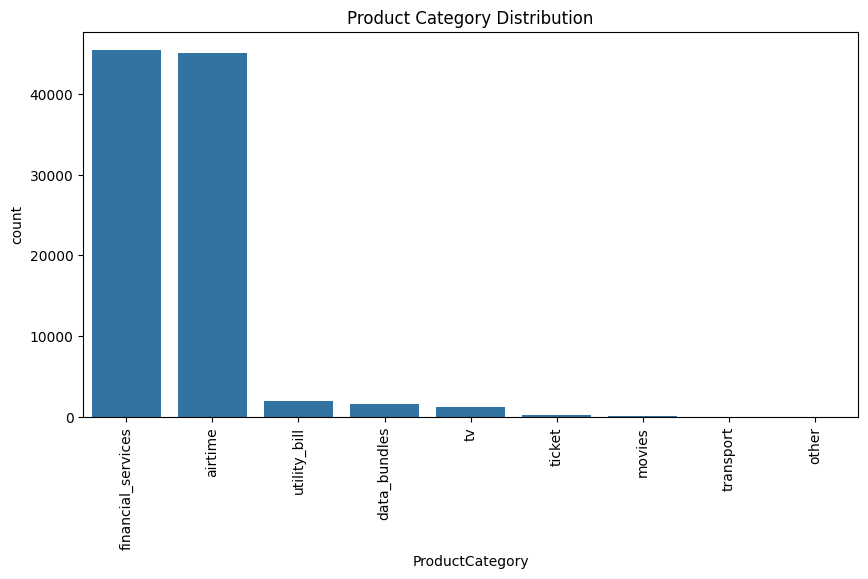

In [18]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="ProductCategory",
    order=df["ProductCategory"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Product Category Distribution")

plt.show()

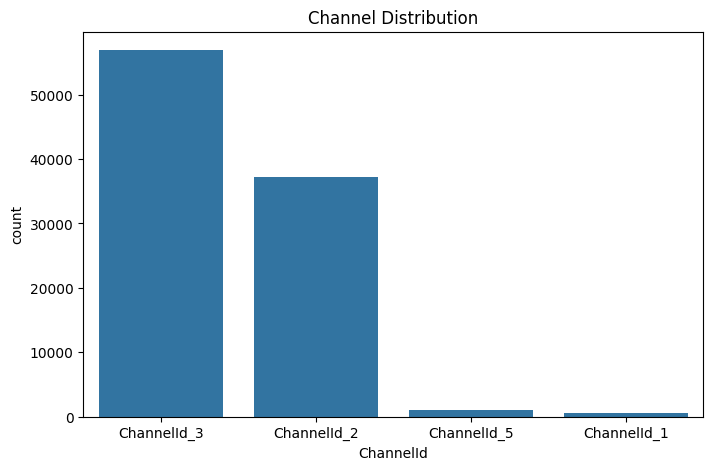

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ChannelId",
    order=df["ChannelId"].value_counts().index
)

plt.title("Channel Distribution")

plt.show()

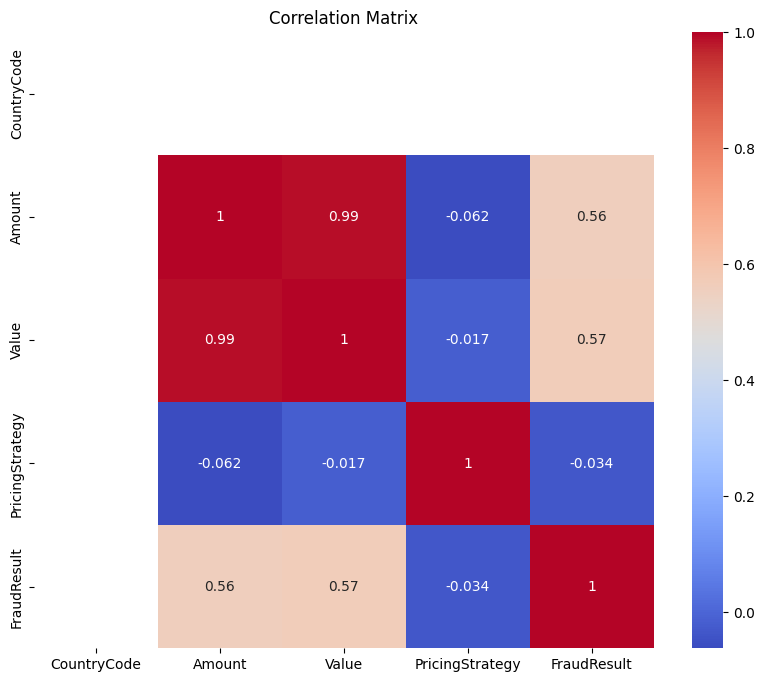

In [20]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

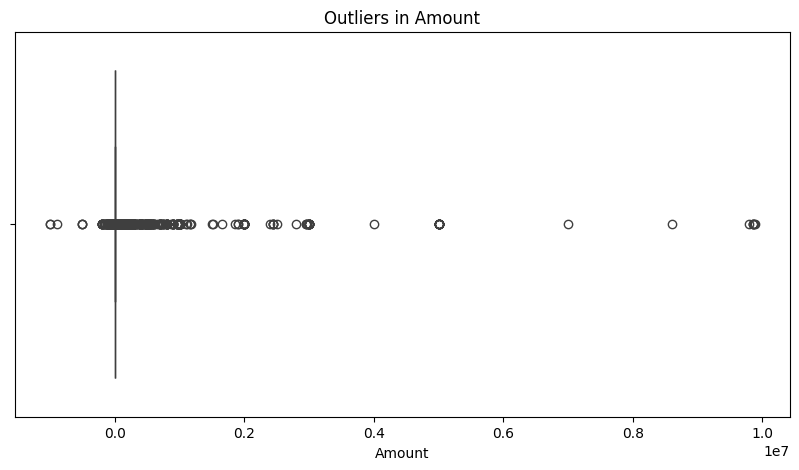

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Amount"])

plt.title("Outliers in Amount")

plt.show()

## Key Insights

1. Transaction amounts show a highly skewed distribution with a few very large transactions.
2. Some product categories dominate transaction volume while others are rarely used.
3. Missing values are concentrated in a limited number of columns and require treatment before modeling.
4. Several numerical features contain significant outliers that may affect model performance.
5. Correlation analysis indicates relationships among transaction-related variables that may be useful for feature engineering.